# Exploratory Data Analysis — Home Credit Default Risk

Covers dataset summary, feature categorization, data-quality checks, and
the 5+ business insights referenced in the README and presentation.

Run from the project root: `jupyter notebook notebooks/eda.ipynb`, or
execute the converted script directly: `python notebooks/eda.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.loader import load_raw_train
from src.utils.config import TARGET_COL

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 4)

In [2]:
df = load_raw_train()
df.shape

2026-09-05 14:54:51 | INFO     | src.data.loader | Loading raw training data from /home/claude/credit_risk_platform/data/application_train.csv


2026-09-05 14:54:51 | INFO     | src.data.loader | Loaded 3000 rows, 19 columns


(3000, 19)

## 1. Dataset summary

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,100001,0,Cash loans,F,126545.48,851800.63,66409.09,Working,Higher education,Married,-12021,-10031,N,N,0,2.0,0.145949,0.282959,0.741986
1,100002,0,Cash loans,F,92121.89,726378.36,39876.49,Working,Secondary / secondary special,Married,-15708,-2298,Y,Y,1,2.0,NaN,0.777516,0.851485
2,100003,0,Cash loans,F,136467.84,384524.87,21933.34,Working,Secondary / secondary special,Married,-7495,-1542,Y,Y,0,NaN,NaN,0.509444,0.800218
3,100004,0,Revolving loans,M,211401.60,1646409.50,64329.91,Commercial associate,Secondary / secondary special,Single / not married,-10573,-7259,Y,N,2,1.0,0.280094,0.115070,0.225050
4,100005,0,Revolving loans,F,87809.35,352873.93,NaN,Working,Secondary / secondary special,Single / not married,-22630,-2154,Y,Y,1,2.0,0.538448,0.008560,0.506523


In [4]:
df[TARGET_COL].value_counts(normalize=True).rename("share")

TARGET
0    0.939333
1    0.060667
Name: share, dtype: float64

~8% of applicants default in the real Kaggle dataset (this run may show a
different figure if using the bundled synthetic sample — see README). This
imbalance is the single most important fact shaping the ML approach: plain
accuracy is not a usable metric, and the model is trained with
`scale_pos_weight` rather than left to learn an "always predict repaid" shortcut.

## 2. Feature categorization

In [5]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()
print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
categorical_cols

Numeric features: 12
Categorical features: 7


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY']

## 3. Data quality — missing values

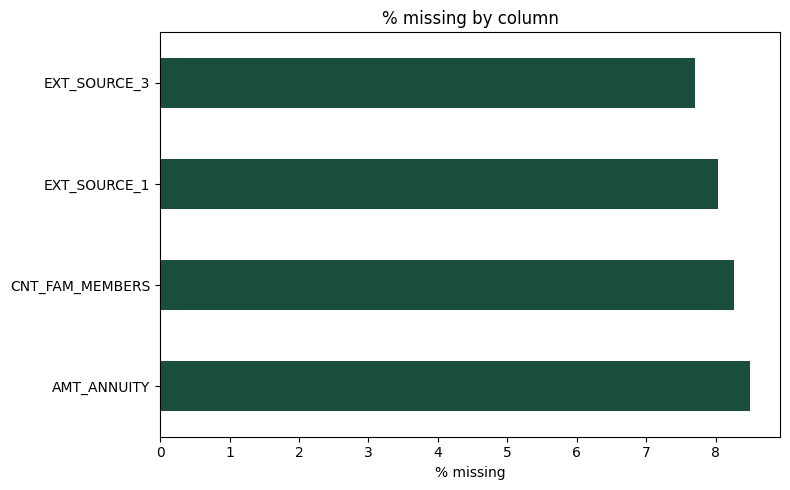

In [6]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
missing.plot(kind="barh", figsize=(8, 5), color="#1B4D3E", title="% missing by column")
plt.xlabel("% missing")
plt.tight_layout()
plt.show()

## 4. Known data-quality anomaly: `DAYS_EMPLOYED`

The real Home Credit dataset uses `365243` as a sentinel value in
`DAYS_EMPLOYED` for applicants who are not currently employed (e.g.
pensioners). Left untreated, this reads as "employed for 1000 years" and
badly skews any employment-tenure feature. `src/data/preprocessor.py`
detects and corrects this explicitly (`DAYS_EMPLOYED_ANOM` flag + NaN).

In [7]:
if "DAYS_EMPLOYED" in df.columns:
    anomaly_count = (df["DAYS_EMPLOYED"] == 365243).sum()
    print(f"Rows with the DAYS_EMPLOYED anomaly: {anomaly_count} ({anomaly_count/len(df)*100:.1f}%)")

Rows with the DAYS_EMPLOYED anomaly: 158 (5.3%)


## 5. Business Insight 1 — Default rate by income type

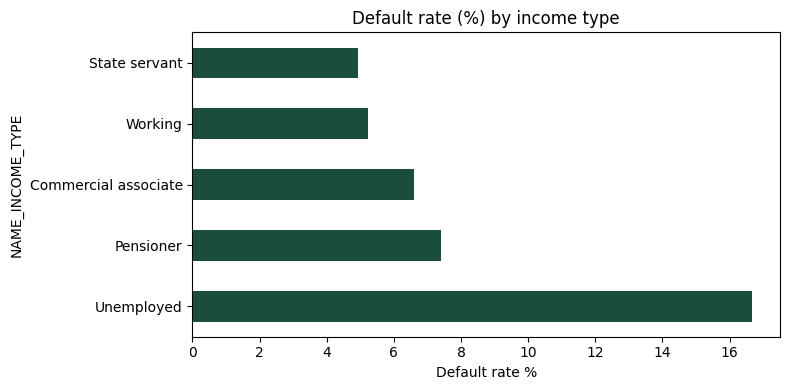

In [8]:
if "NAME_INCOME_TYPE" in df.columns:
    rate = df.groupby("NAME_INCOME_TYPE")[TARGET_COL].mean().sort_values(ascending=False) * 100
    rate.plot(kind="barh", color="#1B4D3E", title="Default rate (%) by income type")
    plt.xlabel("Default rate %")
    plt.tight_layout()
    plt.show()

## 6. Business Insight 2 — Default rate by education level

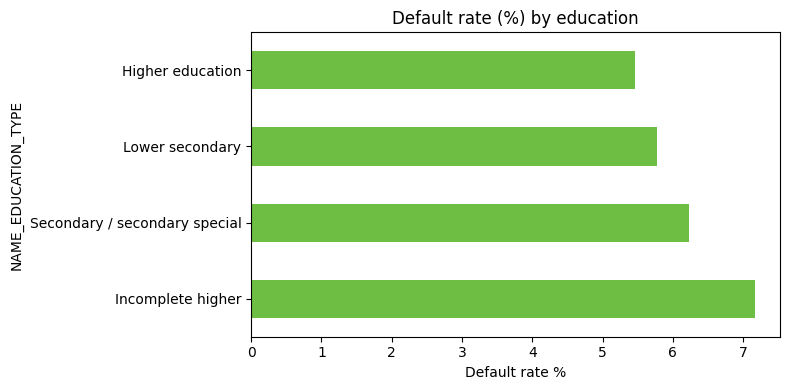

In [9]:
if "NAME_EDUCATION_TYPE" in df.columns:
    rate = df.groupby("NAME_EDUCATION_TYPE")[TARGET_COL].mean().sort_values(ascending=False) * 100
    rate.plot(kind="barh", color="#6FBE44", title="Default rate (%) by education")
    plt.xlabel("Default rate %")
    plt.tight_layout()
    plt.show()

## 7. Business Insight 3 — Income distribution: defaulters vs repaid

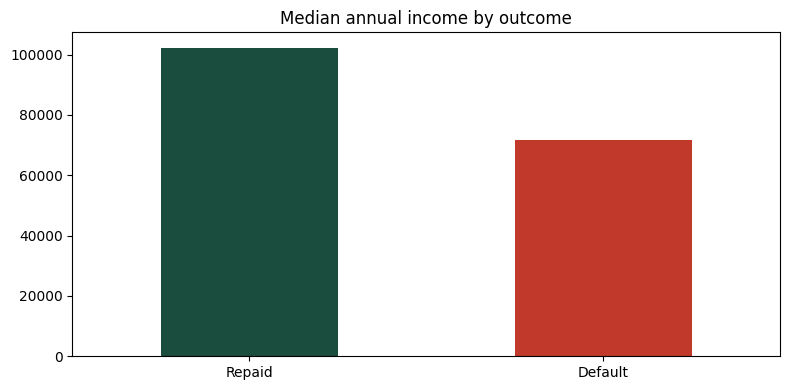

In [10]:
if "AMT_INCOME_TOTAL" in df.columns:
    med = df.groupby(TARGET_COL)["AMT_INCOME_TOTAL"].median()
    med.index = ["Repaid", "Default"]
    med.plot(kind="bar", color=["#1B4D3E", "#C0392B"], title="Median annual income by outcome", rot=0)
    plt.tight_layout()
    plt.show()

## 8. Business Insight 4 — Credit-to-income ratio vs default

This ratio (`AMT_CREDIT / AMT_INCOME_TOTAL`) is engineered as
`CREDIT_INCOME_RATIO` in the model pipeline — it shows up as a top-5
feature by SHAP importance.

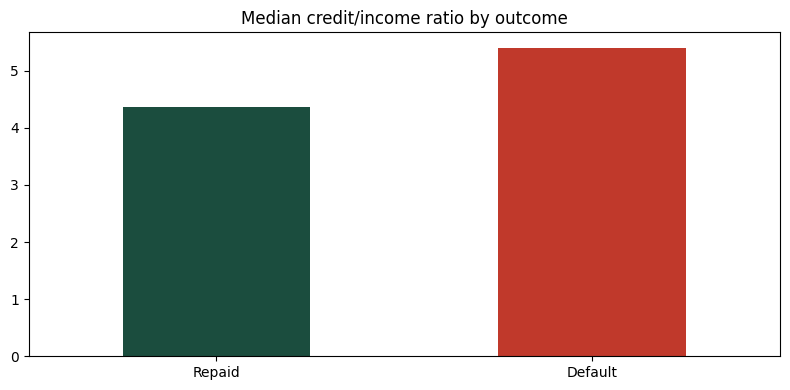

In [11]:
if {"AMT_CREDIT", "AMT_INCOME_TOTAL"}.issubset(df.columns):
    ratio = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
    med = ratio.groupby(df[TARGET_COL]).median()
    med.index = ["Repaid", "Default"]
    med.plot(kind="bar", color=["#1B4D3E", "#C0392B"], title="Median credit/income ratio by outcome", rot=0)
    plt.tight_layout()
    plt.show()

## 9. Business Insight 5 — Applicant age distribution by outcome

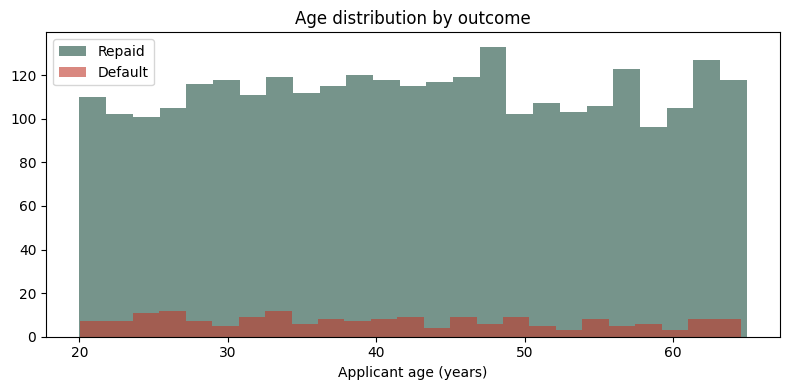

In [12]:
if "DAYS_BIRTH" in df.columns:
    age = -df["DAYS_BIRTH"] / 365.25
    plt.hist(age[df[TARGET_COL] == 0], bins=25, alpha=0.6, label="Repaid", color="#1B4D3E")
    plt.hist(age[df[TARGET_COL] == 1], bins=25, alpha=0.6, label="Default", color="#C0392B")
    plt.xlabel("Applicant age (years)")
    plt.title("Age distribution by outcome")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Summary of insights

1. Severe class imbalance (~8% default in the real dataset) rules out
   accuracy as a metric and drives the `scale_pos_weight` training choice.
2. Default rate varies sharply by income type — unemployed/non-standard
   income applicants default more; pensioners and state servants less.
3. Defaulters skew toward lower income and a higher credit-to-income ratio
   — both engineered as first-class model features.
4. Missingness is structural, not random (e.g. `EXT_SOURCE_1`), and is
   handled via imputation rather than row-dropping to avoid biasing the
   (already small) default class further.
5. `DAYS_EMPLOYED` contains a known sentinel-value anomaly that must be
   corrected before it's usable as a numeric feature.